##### An alternative approach to feature selection is feature extraction. There are some fundamental techniques:
- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)
- None linear method: t-distributed stochastic neighbor embedding (t-SNE) for data viz.

##### The difference between feature selection vs feature extraction:
- Feature selection: keep the original features and apply feature selection algorithms.
- Feature extraction: transform or project the data onto a new feature space.

#### PCA (Unsupervised):
- find the directions of maximum variance in high-dimensional data and projects the data onto a new subspace with equal or fewer dimensions than the original ones. \
<img src="images/pca.png" width=400>
- In theory: we try to find a dxk dimensional transformation matrix W that allows us to map the vector of the original features x of the dataset (d dimension) onto a new feature subspace with fewer dimensions (k) to create a new feature vector z = xW.

- Steps:
1. Standardize the d-dimensional dataset
2. Construct the covariance matrix
3. Decomposition the covariance matrix into its eigenvector and eigenvalues
4. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
5. Select k eigenvectors corresponding to the k-leargest eigenvalues.
6. Construct a project matrix from the k selected eigenvector: W
7. Transform the d-dimensional input dataset X using the project matrix W to obtain the new k-dimensional feature subspace.

In [104]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

# Step 0: get the data and split it
df_wine = pd.read_csv(
    'https://archive.ics.uci.edu/ml/'
    'machine-learning-databases/wine/wine.data',
    header=None
)

print(df_wine.info())

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', \
                    'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', \
                        'Proanthocyanins','Color intensity', 'Hue','OD280/OD315 of diluted wines', \
                        'Proline']

X = df_wine.iloc[:, 1:].values
y = df_wine.iloc[:, 0].values

print(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True, random_state=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    int64  
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    float64
 5   5       178 non-null    int64  
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    float64
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
[1 2 3]


In [105]:
# Step 1: standardize the feature
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [106]:
# Step 2: construct the covariance matrix
# np.cov() expect variables as rows not columns -> X_train.T
cov_matrix = np.cov(X_train.T)

# Step 3: decomposition the cov_matrix into eigenvalues and eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Step 4: sorted the eigenvalues by decreasing order
sorted_eigen_values = sorted(eigen_values, reverse=True)

##### Calculate the explained variance ratio:
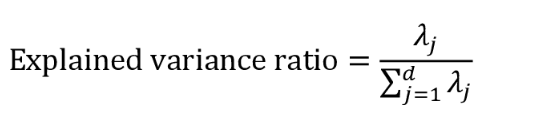

In [107]:
total = np.sum(sorted_eigen_values)
explained_var_ratio = sorted_eigen_values / total
print(explained_var_ratio)
cum_sum_explained_var_ratio = np.cumsum(explained_var_ratio)
print(cum_sum_explained_var_ratio)

[0.3621 0.203  0.1192 0.0679 0.0626 0.0429 0.0368 0.0274 0.0218 0.0196
 0.0163 0.0129 0.0076]
[0.3621 0.5651 0.6843 0.7522 0.8148 0.8576 0.8944 0.9218 0.9436 0.9632
 0.9795 0.9924 1.    ]


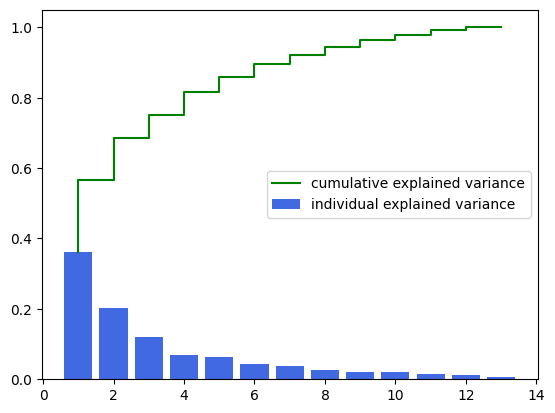

In [108]:
import matplotlib.pyplot as plt

plt.bar(range(1, eigen_values.shape[0]+1), explained_var_ratio, color='royalblue', label="individual explained variance")
plt.step(range(1, eigen_values.shape[0]+1), cum_sum_explained_var_ratio, color='green', label="cumulative explained variance")
plt.legend()

In [109]:
# step 4: modified: sorted a tuple (eigen_values, eigen_vectors)
eigen_tuple = [(np.abs(eigen_values[i]), eigen_vectors[:, i]) for i in range(len(eigen_values))]

eigen_tuple.sort(key=lambda x: x[0], reverse=True)

In [110]:
eigen_tuple[0][1].reshape(-1, 1)

array([[-0.1449],
       [ 0.2513],
       [-0.039 ],
       [ 0.203 ],
       [-0.1527],
       [-0.405 ],
       [-0.4265],
       [ 0.2972],
       [-0.328 ],
       [ 0.07  ],
       [-0.2891],
       [-0.3719],
       [-0.2851]])

In [111]:
# step 5 & 6: get the first 2 dimension -> W
W_2 = np.hstack((eigen_tuple[0][1][:, np.newaxis],
              eigen_tuple[1][1][:, np.newaxis]))
W_2

array([[-0.1449,  0.4644],
       [ 0.2513,  0.2619],
       [-0.039 ,  0.2905],
       [ 0.203 ,  0.0007],
       [-0.1527,  0.3261],
       [-0.405 ,  0.0552],
       [-0.4265, -0.0088],
       [ 0.2972,  0.0009],
       [-0.328 ,  0.0456],
       [ 0.07  ,  0.5313],
       [-0.2891, -0.2891],
       [-0.3719, -0.1941],
       [-0.2851,  0.3411]])

In [112]:
# for k-dimensional extraction
k = 4
W_k = np.hstack(tuple([eigen_tuple[i][1].reshape(-1, 1) for i in range(k)]))
W_k

array([[-0.1449,  0.4644,  0.1999, -0.0965],
       [ 0.2513,  0.2619, -0.0821,  0.4984],
       [-0.039 ,  0.2905, -0.6218, -0.217 ],
       [ 0.203 ,  0.0007, -0.628 ,  0.1024],
       [-0.1527,  0.3261, -0.1208, -0.1649],
       [-0.405 ,  0.0552, -0.1302,  0.1054],
       [-0.4265, -0.0088, -0.1501,  0.0799],
       [ 0.2972,  0.0009, -0.2097, -0.3605],
       [-0.328 ,  0.0456, -0.1067,  0.446 ],
       [ 0.07  ,  0.5313,  0.1128, -0.0129],
       [-0.2891, -0.2891, -0.0722, -0.4631],
       [-0.3719, -0.1941, -0.1545,  0.1829],
       [-0.2851,  0.3411,  0.1446, -0.2512]])

In [113]:
# step 7: transform the original feature vector to the new reduced dimension vector
X_train_reduced = X_train.dot(W_2)
X_test_reduced = X_test.dot(W_2)

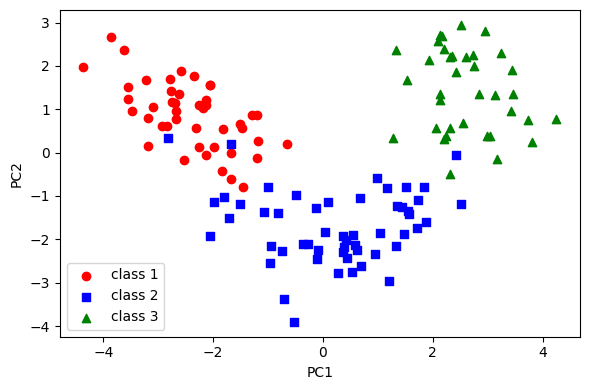

In [114]:
# plot X_train_reduced
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

plt.figure(figsize=(6,4))
for idx, label in enumerate(np.unique(y)):
    plt.scatter(X_train_reduced[y_train==label, 0], X_train_reduced[y_train==label, 1], 
                color=colors[idx], marker=markers[idx], label=f"class {label}")

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

#### Implementation in sklearn

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

pca = PCA(n_components=2)
model = LogisticRegression()

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(pca.explained_variance_) # eigenvalues
print(pca.explained_variance_ratio_) # ratio

[4.7431 2.6586]
[0.3621 0.203 ]


In [116]:
# training with pca
model.fit(X_train_pca, y_train)
preds = model.predict(X_test_pca)
accuracy = accuracy_score(preds, y_test)
print(accuracy)

0.9777777777777777


In [117]:
# training without dimensional reduction
new_model = LogisticRegression()
new_model.fit(X_train, y_train)
new_preds = new_model.predict(X_test)
new_accuracy = accuracy_score(new_preds, y_test)
print(new_accuracy)

0.9777777777777777


##### Assessing the contributions of the original features to the PCs
these contributions are called loadings can can be calculated by eigen_vecs * sqrt(eigen_vals)

In [118]:
loadings = eigen_vectors * np.sqrt(eigen_values)

In [119]:
loadings.shape

(13, 13)

In [120]:
vars = df_wine.columns[1:]
print(vars)

first_PC = loadings[:, 0]

Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
       'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')


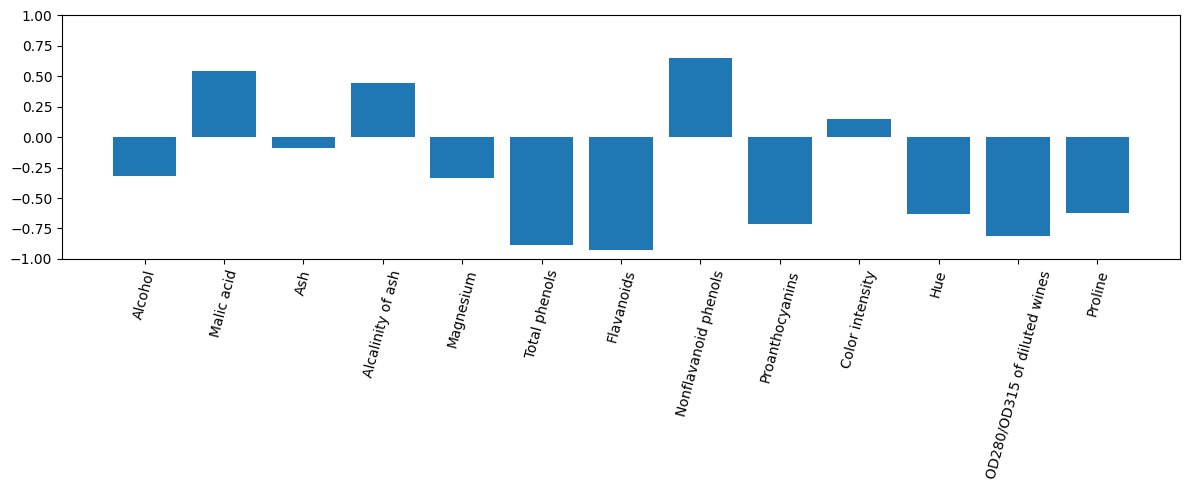

In [121]:
plt.figure(figsize=(12, 5))
plt.bar(range(13), first_PC)
plt.ylim([-1, 1])
plt.xticks(range(13), vars, rotation=75)
plt.tight_layout()
plt.show()

In [122]:
# similarly from PCA:
pca_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
first_PC_pca = pca_loadings[:, 0]

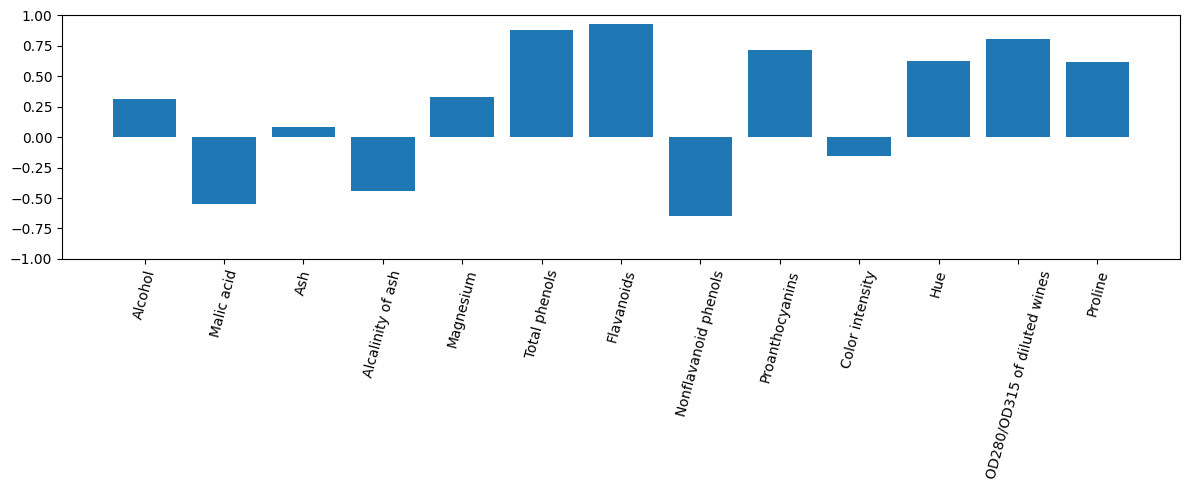

In [123]:
plt.figure(figsize=(12, 5))
plt.bar(range(13), first_PC_pca)
plt.ylim([-1, 1])
plt.xticks(range(13), vars, rotation=75)
plt.tight_layout()
plt.show()

#### Linear Discriminant Analysis (Supervised):
- The goal of LDA is to find the feature subspace that optimizes class separability. 

<img src='images/lda.png' width=400> 

- Assumptions: \
(1) normal distribution \
(2) all classes have identical/same covariance matrix: Sigma_1 = Sigma_2 = ... = Sigma \
(3) samples are i.i.d

##### The inner working of LDA:
1. Standard the dataset
2. Compute the mean vector for each class
3. Construct the between-class scatter matrix S_B and the within-class scatter matrix S_W
4. Compute the eig_vecs and eig_vals of the matrix S_W^-1.S_B
5. Sort the eig_vals
6. Choose k values to construc a transformation matrix W
7. Project the samples onto the new feature subspace using the transformation matrix W

In [124]:
np.set_printoptions(precision=4)
# Step 2: compute the mean vector
mean_vectors = []
for label in np.unique(y_train):
    mean_vectors.append(np.mean(X_train[y_train==label], axis=0))

print(mean_vectors)

[array([ 0.8918, -0.3565,  0.3238, -0.7116,  0.5217,  0.9329,  0.9922,
       -0.6167,  0.6613,  0.1901,  0.4909,  0.7681,  1.1632]), array([-0.9246, -0.3715, -0.4092,  0.2578, -0.4754, -0.132 ,  0.007 ,
        0.1047, -0.0308, -0.8526,  0.3995,  0.2503, -0.7697]), array([ 0.2712,  0.9827,  0.2067,  0.4902,  0.0623, -0.9459, -1.2229,
        0.5996, -0.763 ,  1.0228, -1.1882, -1.3074, -0.2885])]


In [125]:
# Step 3a: compute the with-inclass Scatter Matrix: S_W = sum(S_i) for i is class i.
# S_i = sum((x-m_i)(x-m_i).T)
d = 13
S_W = np.zeros((d, d))

for label, mean_vector in zip(range(1, 4), mean_vectors):
    S_i = np.zeros((d, d))
    S_i = np.sum([(row.reshape(-1, 1)-mean_vector.reshape(-1,1)).dot((row.reshape(-1, 1)-mean_vector.reshape(-1,1)).T)
                   for row in X_train[y_train==label]], axis=0)
    S_W += S_i
print(S_W.shape)

(13, 13)


In [126]:
print(df_wine.iloc[:,0].value_counts())
print(np.bincount(y_train))
print(np.bincount(y_test))

Class label
2    71
1    59
3    48
Name: count, dtype: int64
[ 0 44 53 36]
[ 0 15 18 12]


In [127]:
S_W.shape

(13, 13)

In [128]:
# scaling version
d = 13
S_W = np.zeros((d, d))
S_W += np.sum([np.cov(X_train[y_train==label].T) for label in range(1,4)], axis=0)

In [129]:
# step 3b: compute S_B
mean_overall = np.mean(X_train, axis=0).reshape(-1,1)

S_B = np.sum([len(X_train[y_train==label]) * (mean_vector.reshape(-1, 1) - mean_overall).dot(
            (mean_vector.reshape(-1, 1) - mean_overall).T)
            for label, mean_vector in zip(range(1,4), mean_vectors)], axis=0)

In [130]:
S_W.shape

(13, 13)

In [131]:
# step 4: calculating eigen_vectors, eigen_values
eig_values, eig_vectors = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

In [132]:
eig_pairs = [(np.abs(eig_values[i]), eig_vectors[:, i]) for i in range(len(eig_values))]

sorted_eig_pairs = sorted(eig_pairs, key=lambda x: x[0].real, reverse=True)

for eig_pair in sorted_eig_pairs:
    print(eig_pair[0])

436.42812409134984
198.03352841307154
6.254560456741804e-14
3.898767854560197e-14
3.238320424776495e-14
1.8833320308089957e-14
1.8833320308089957e-14
1.5113745834603865e-14
1.1014493967769261e-14
1.1014493967769261e-14
5.4578142816817965e-15
1.9637583378749622e-15
0.0


In [133]:
total = sum(eig_values.real)
discr_ratio = [(i/total) for i in sorted(eig_values.real, reverse=True)]
cum_discr_ratio = np.cumsum(discr_ratio)

print(discr_ratio)
print(cum_discr_ratio)

[0.6878715559382187, 0.3121284440617811, 9.858059083717776e-17, 2.423605758915961e-17, 2.423605758915961e-17, 0.0, -2.0818966398635877e-18, -2.0818966398635877e-18, -3.09515686270933e-18, -8.602276055831067e-18, -2.3821370093756043e-17, -5.104044368944626e-17, -6.145001576014126e-17]
[0.6879 1.     1.     1.     1.     1.     1.     1.     1.     1.
 1.     1.     1.    ]


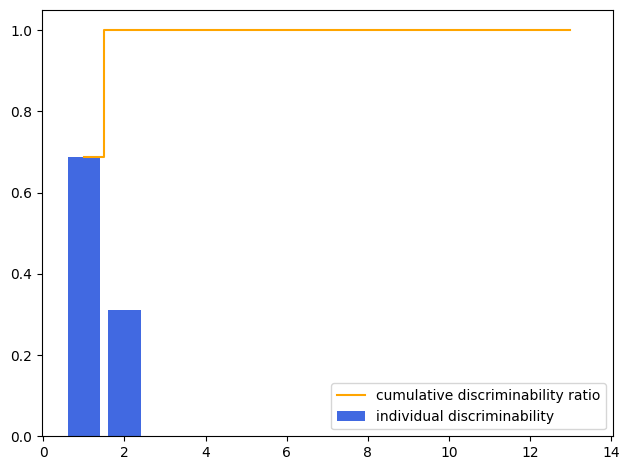

In [134]:
x_axis = list(range(1, 14))

plt.bar(x_axis, discr_ratio, color="royalblue", label="individual discriminability", align="center")
plt.step(x_axis, cum_discr_ratio, color="orange", label="cumulative discriminability ratio", where='mid')
plt.legend()
plt.tight_layout()
plt.show()

In [135]:
# step 5 and 6: select k and construct W
k = 2

W_lda = np.hstack(tuple([sorted_eig_pairs[i][1].reshape(-1, 1).real for i in range(k)]))
W_lda

array([[-0.1371, -0.4253],
       [ 0.089 , -0.1253],
       [-0.0167, -0.3838],
       [ 0.2207,  0.284 ],
       [-0.032 , -0.0696],
       [ 0.2014, -0.0958],
       [-0.7371,  0.4361],
       [-0.1023,  0.1381],
       [-0.012 ,  0.0489],
       [ 0.3182, -0.1564],
       [-0.0976,  0.2122],
       [-0.3614,  0.0139],
       [-0.2956, -0.5293]])

In [136]:
# step 7: transform X
X_train_lda = X_train.dot(W_lda)
X_test_lda = X_test.dot(W_lda)

In [137]:
len(y_train), len(y_test), len(X_train_lda)

(133, 45, 133)

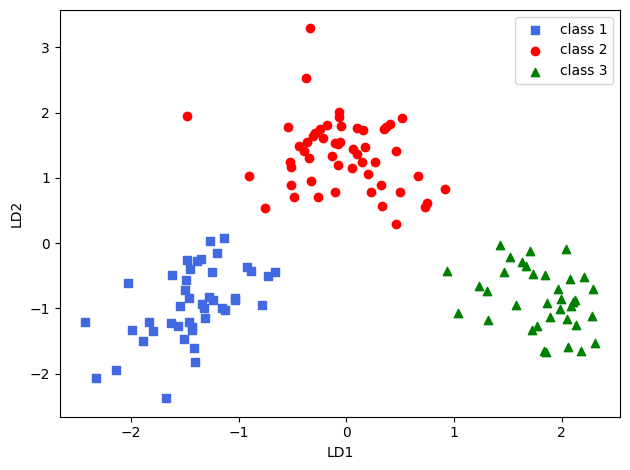

In [142]:
# plot new projections
plt.scatter(X_train_lda[y_train==1,0], X_train_lda[y_train==1,1], color="royalblue", marker="s", label="class 1")
plt.scatter(X_train_lda[y_train==2,0], X_train_lda[y_train==2,1], color="red", marker="o", label="class 2")
plt.scatter(X_train_lda[y_train==3,0], X_train_lda[y_train==3,1], color="green", marker="^", label="class 3")
plt.legend()
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.tight_layout()
plt.show()

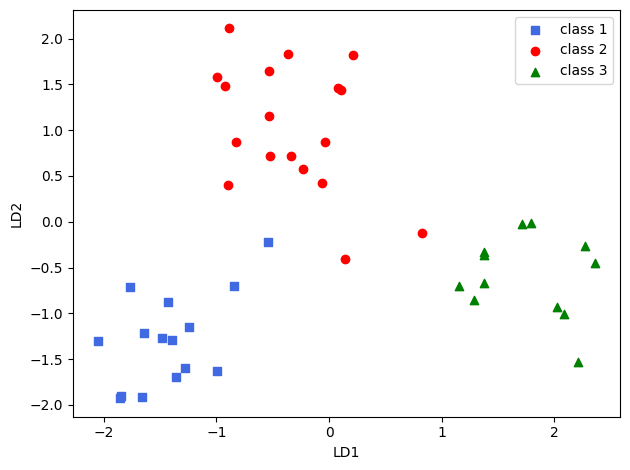

In [144]:
plt.scatter(X_test_lda[y_test==1,0], X_test_lda[y_test==1,1], color="royalblue", marker="s", label="class 1")
plt.scatter(X_test_lda[y_test==2,0], X_test_lda[y_test==2,1], color="red", marker="o", label="class 2")
plt.scatter(X_test_lda[y_test==3,0], X_test_lda[y_test==3,1], color="green", marker="^", label="class 3")
plt.legend()
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.tight_layout()
plt.show()

##### LDA via sklearn

In [151]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda_skl = lda.fit_transform(X_train, y_train)
X_test_lda_skl = lda.transform(X_test)

model_lda = LogisticRegression(random_state=1, solver='lbfgs')
model_lda.fit(X_train_lda_skl, y_train)
preds = model_lda.predict(X_test_lda_skl)
accuracy = accuracy_score(preds, y_test)
print(accuracy)


0.9555555555555556


#### Nonlinear dimensionality reduction and visualization
- For nonlinear problem, the linear transformation techniques like PCA, LDA for dimensional reduction.

<img src="images/nonlinear_problem.png" width=450>
<img src="images/swiss_roll.png" width=450>

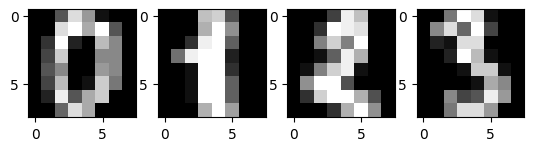

In [158]:
from sklearn.datasets import load_digits

digits = load_digits()

fig, ax = plt.subplots(1, 4)

for i in range(4):
    ax[i].imshow(digits.images[i], cmap='gray')
plt.show()

In [165]:
digits.data.shape

(1797, 64)

In [166]:
X = digits.data
y = digits.target

In [167]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, init='pca', random_state=1)

X_digits_tsne = tsne.fit_transform(X)

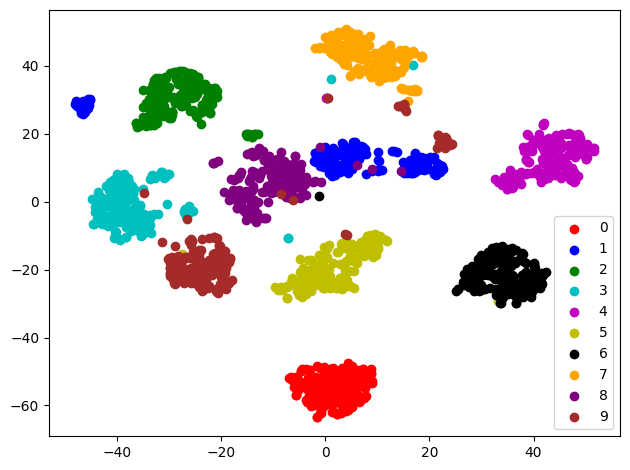

In [168]:
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']
labels = digits.target_names
for i in range(len(labels)):
    plt.scatter(X_digits_tsne[y==i, 0], X_digits_tsne[y==i, 1], color=colors[i], label=f"{labels[i]}")
    
plt.tight_layout()
plt.legend()
plt.show()